In [1]:
import numpy as np
from PIL import Image
from IPython.display import display

In [2]:
from __future__ import annotations

NUM_ROWS = 28
NUM_COLS = 28
NUM_LABELS = 10

class Data:
  def __init__(self, pixels: list[list[int]], label: int):
    self.pixels = pixels
    self.flattened_pixels: list[int] = []
    for row in self.pixels:
      assert len(row) == NUM_ROWS
      self.flattened_pixels.extend(row)
    self.flattened_pixels = [pixel / 255.0 for pixel in self.flattened_pixels]
    
    self.label = label
  
  @classmethod
  def from_csv_row(cls, csv: list[int]) -> Data:
    label = csv[0]
    pixels: list[list[int]] = []
    for row in range(NUM_ROWS):
      start_index = 1 + row * NUM_ROWS
      pixels.append(csv[start_index : start_index + NUM_COLS])

    return cls(pixels, label)
  
  def to_image(self) -> Image:
    pixel_array = np.array(self.pixels, dtype=np.uint8)
    return Image.fromarray(pixel_array, mode='L')
  
  def label_to_one_hot(self) -> list[int]:
    result = [0] * NUM_LABELS
    result[self.label] = 1
    return result

In [3]:
lines: list[str] = []
datas: list[Data] = []

with open('data/MNIST_CSV/mnist_train.csv') as f:
  lines = f.readlines()

for line in lines:
  datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [4]:
print(datas[0].label)
print(datas[0].label_to_one_hot())
display(datas[0].to_image())

5
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [5]:
distinct_labels = set()
for data in datas:
  distinct_labels.add(data.label)

In [6]:
distinct_labels

: 

## Train

In [ ]:
from src.deep_learning.layer import get_layer
from src.deep_learning.multi_layer_perceptron import MultiLayerPerceptron
from src.deep_learning.op import TANH
from src.deep_learning.value import Value

from src.deep_learning.util import xavier_uniform
from src.deep_learning.util import zero_all_gradients
from src.deep_learning.util import softmax
from src.deep_learning.util import cross_entropy
from datetime import datetime

In [ ]:
# build graph

input_values = [Value(0.0, label=f'pixel_{i}') for i in range(NUM_ROWS*NUM_COLS)]
output_values = [Value(0.0, label=f'label_{i}') for i in range(len(distinct_labels))]

multi_layer_perceptron = MultiLayerPerceptron(
    layers=[
        get_layer(
            num_weights_per_neuron=NUM_ROWS*NUM_COLS,
            num_neurons=32,
            activation=TANH,
            fn_weight_initializer=lambda: xavier_uniform(NUM_ROWS*NUM_COLS, 32),
        ),
        get_layer(
            num_weights_per_neuron=32,
            num_neurons=NUM_LABELS,
        ),
    ],
)
predicted_output = multi_layer_perceptron.build_graph(input_values)
softmax_output = softmax(predicted_output)
loss = cross_entropy(
    distribution=output_values,
    predicted_distribution=softmax_output,
)

### debugging

In [29]:
loss.gradient

0.0

In [30]:
for value in softmax_output:
  print(value.gradient)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [31]:
import matplotlib.pyplot as plt

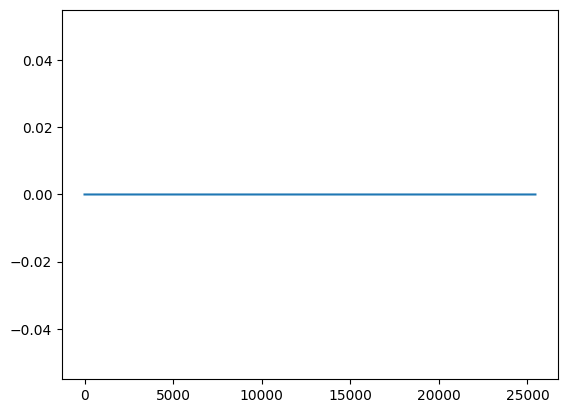

In [32]:
i = 0
gradients: list[float] = []
for layer in multi_layer_perceptron.layers:
  for neuron in layer.neurons:
    for weight in neuron.weight_values:
      gradients.append(weight.gradient)
    gradients.append(neuron.bias_value.gradient)
plt.plot(gradients)

### end debugging

In [33]:
data_index = 0

In [34]:
losses: list[float] = []

In [32]:
for i in range(len(datas) * 10):
  # compute loss
  data = datas[data_index]
  for input_value, pixel in zip(input_values, data.flattened_pixels, strict=True):
    input_value.data = float(pixel)
  for output_value, label_one_hot in zip(output_values, data.label_to_one_hot(), strict=True):
    output_value.data = label_one_hot
  loss.forward()
  losses.append(loss.data)

  if i % 100 == 0 and i > 0:
    window = losses[-100:]
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} mean_t100_loss={sum(window)/len(window):.4f}')

  # backwards
  zero_all_gradients(loss)
  loss.gradient = 1.0
  loss.backward()

  # adjust parameters
  alpha = 0.01
  for layer in multi_layer_perceptron.layers:
    for neuron in layer.neurons:
      for weight_value in neuron.weight_values:
        weight_value.data = weight_value.data + (weight_value.gradient * -alpha)
      neuron.bias_value.data = neuron.bias_value.data + (neuron.bias_value.gradient * -alpha)

  # update state
  data_index = (data_index + 1) % len(datas)

18:45:40 i=100 mean_t100_loss=0.1595
18:45:54 i=200 mean_t100_loss=0.2915
18:46:09 i=300 mean_t100_loss=0.2238
18:46:23 i=400 mean_t100_loss=0.0554
18:46:37 i=500 mean_t100_loss=0.3224
18:46:51 i=600 mean_t100_loss=0.0665
18:47:05 i=700 mean_t100_loss=0.2413
18:47:19 i=800 mean_t100_loss=0.1765
18:47:33 i=900 mean_t100_loss=0.2179
18:47:48 i=1000 mean_t100_loss=0.2287
18:48:02 i=1100 mean_t100_loss=0.3865
18:48:16 i=1200 mean_t100_loss=0.3286
18:48:30 i=1300 mean_t100_loss=0.3626
18:48:44 i=1400 mean_t100_loss=0.3439
18:48:59 i=1500 mean_t100_loss=0.1353
18:49:13 i=1600 mean_t100_loss=0.2383
18:49:27 i=1700 mean_t100_loss=0.1751
18:49:41 i=1800 mean_t100_loss=0.0789
18:49:55 i=1900 mean_t100_loss=0.1091
18:50:10 i=2000 mean_t100_loss=0.2213
18:50:24 i=2100 mean_t100_loss=0.1885
18:50:38 i=2200 mean_t100_loss=0.0890
18:50:52 i=2300 mean_t100_loss=0.0667
18:51:06 i=2400 mean_t100_loss=0.1104
18:51:21 i=2500 mean_t100_loss=0.1505
18:51:35 i=2600 mean_t100_loss=0.1289
18:51:50 i=2700 mean_

KeyboardInterrupt: 

In [33]:
import matplotlib.pyplot as plt

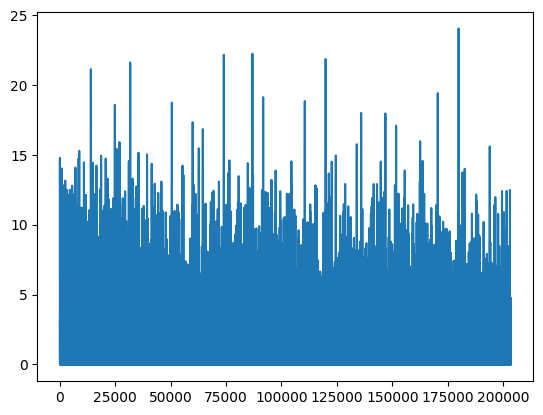

In [34]:
# noisy
plt.plot(losses)

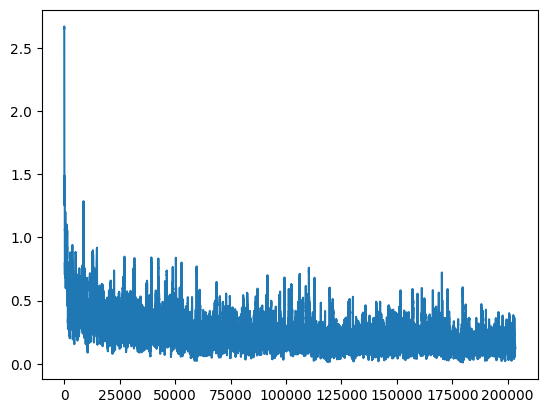

In [35]:
# smooth
mean_t100_losses: list[float] = []
for i in range(100, len(losses)):
  mean_t100_losses.append(sum(losses[i-100:i]) / 100)

plt.plot(mean_t100_losses)

## Pickle

In [36]:
import pickle

class Model:
  def __init__(
      self,
      input_values: list[Value],
      output_values: list[Value],
      multi_layer_perceptron_output: Value,
      softmax_output: list[Value],
      loss: Value,
  ):
    self.input_values = input_values
    self.output_values = output_values
    self.multi_layer_perceptron_output = multi_layer_perceptron_output
    self.softmax_output = softmax_output
    self.loss = loss

In [37]:
model = Model(
    input_values=input_values,
    output_values=output_values,
    multi_layer_perceptron_output=predicted_output,
    softmax_output=softmax_output,
    loss=loss,
)

# NOTE: commented out after running to prevent dumb accidental overwrite errors
with open('data/MNIST_CSV/model.pkl', 'wb') as file:
  pickle.dump(model, file)

In [38]:
model: Model = None
with open('data/MNIST_CSV/model.pkl', 'rb') as file:
  model = pickle.load(file)

## Predict

In [39]:
data = datas[0]
for input_value, pixel in zip(model.input_values, data.flattened_pixels, strict=True):
  input_value.data = float(pixel)
for output_value, label_one_hot in zip(model.output_values, data.label_to_one_hot(), strict=True):
  output_value.data = label_one_hot
model.loss.forward()

for i, p_label in enumerate(model.softmax_output):
  print(f'P({i}): {p_label.data:4f}')

prediction = max(range(len(model.softmax_output)), key=lambda i: model.softmax_output[i].data)
prediction

P(0): 0.000001
P(1): 0.000005
P(2): 0.000000
P(3): 0.029199
P(4): 0.000000
P(5): 0.970760
P(6): 0.000000
P(7): 0.000000
P(8): 0.000002
P(9): 0.000032


5

## Test

In [40]:
lines: list[str] = []
test_datas: list[Data] = []

with open('data/MNIST_CSV/mnist_test.csv') as f:
  lines = f.readlines()

for line in lines:
  test_datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [41]:
print(test_datas[0].label)
print(test_datas[0].label_to_one_hot())
display(test_datas[0].to_image())

7
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


In [42]:
class TestOutcome:
  def __init__(
      self,
      test_case_index: int,
      correct_label: int,
      predicted_label: int,
      predicted_label_to_probability: dict[int, float],
  ):
    test_case_index = test_case_index
    self.correct_label = correct_label
    self.predicted_label = predicted_label
    self.predicted_label_to_probability = predicted_label_to_probability

  def __repr__(self) -> str:
    return f'{self.__class__.__name__}({self.__dict__})'

In [43]:
test_outcomes: list[TestOutcome] = []
incorrect_test_outcomes: list[TestOutcome] = []

In [44]:
  from datetime import datetime

In [45]:
for i in range(len(test_datas)):
  # compute prediction
  data = test_datas[i]
  for input_value, pixel in zip(model.input_values, data.flattened_pixels, strict=True):
    input_value.data = float(pixel)
  for output_value, label_one_hot in zip(model.output_values, data.label_to_one_hot(), strict=True):
    output_value.data = label_one_hot
  model.loss.forward()

  predicted_label_to_probability: dict[int, float] = {}
  for label, probability in enumerate(model.softmax_output):
    predicted_label_to_probability[label] = probability.data

  predicted_label = max(predicted_label_to_probability.keys(), key=lambda label: predicted_label_to_probability[label])
  
  test_outcome = TestOutcome(
      test_case_index=i,
      correct_label=data.label,
      predicted_label=predicted_label,
      predicted_label_to_probability=predicted_label_to_probability,
  )
  
  # update state
  test_outcomes.append(test_outcome)
  if test_outcome.correct_label != test_outcome.predicted_label:
    incorrect_test_outcomes.append(test_outcome)

  if i % 100 == 0 and i > 0:
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} current_score={(i - len(incorrect_test_outcomes)) / i:.4f}')

22:05:01 i=100 current_score=0.9600
22:05:04 i=200 current_score=0.9600
22:05:07 i=300 current_score=0.9633
22:05:10 i=400 current_score=0.9625
22:05:13 i=500 current_score=0.9600
22:05:17 i=600 current_score=0.9550
22:05:20 i=700 current_score=0.9500
22:05:23 i=800 current_score=0.9513
22:05:25 i=900 current_score=0.9489
22:05:28 i=1000 current_score=0.9500
22:05:31 i=1100 current_score=0.9500
22:05:34 i=1200 current_score=0.9467
22:05:37 i=1300 current_score=0.9423
22:05:40 i=1400 current_score=0.9414
22:05:43 i=1500 current_score=0.9413
22:05:47 i=1600 current_score=0.9413
22:05:50 i=1700 current_score=0.9424
22:05:53 i=1800 current_score=0.9406
22:05:56 i=1900 current_score=0.9421
22:05:59 i=2000 current_score=0.9420
22:06:02 i=2100 current_score=0.9400
22:06:05 i=2200 current_score=0.9400
22:06:08 i=2300 current_score=0.9400
22:06:11 i=2400 current_score=0.9404
22:06:14 i=2500 current_score=0.9404
22:06:17 i=2600 current_score=0.9404
22:06:20 i=2700 current_score=0.9415
22:06:23 i

KeyboardInterrupt: 

In [ ]:
score = (len(test_outcomes) - len(incorrect_test_outcomes)) / len(test_outcomes)
print(f'{score:4f}=')

0.938719=
